In [22]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from helper_function import plot_decision_boundary, accuracy_fn
from sklearn.decomposition import PCA

In [23]:

def accuracy_fn(y_true, y_pred):
    y_pred_class = torch.round(y_pred)  # convert probabilities to 0 or 1
    return (y_pred_class == y_true).float().mean() * 100

In [24]:
X, y = load_breast_cancer(return_X_y = True)
pca = PCA(n_components = 2)
X = pca.fit_transform(X)

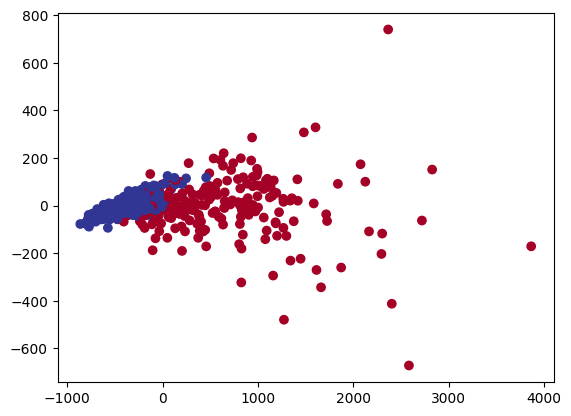

In [25]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [26]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [27]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [29]:
X_train.shape, y_train.unique()

(torch.Size([455, 2]), tensor([0., 1.]))

In [30]:
class BreastCancerClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_features = 2, out_features = 10),
            nn.ReLU(),
            nn.Linear(in_features = 10, out_features = 10),
            nn.ReLU(),
            nn.Linear(in_features = 10, out_features = 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [31]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [32]:
model = BreastCancerClassification().to(device)
model

BreastCancerClassification(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [33]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [34]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [35]:
epochs = 2
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 4.728647708892822 | Test Loss: 0.44718897342681885
Train Accuracy: 10.329670906066895 | Test Accuracy: 69.2982406616211

Train Loss: 0.15340112149715424 | Test Loss: 0.11186494678258896
Train Accuracy: 93.62637329101562 | Test Accuracy: 95.6140365600586

Train Loss: 0.15263678133487701 | Test Loss: 0.10454705357551575
Train Accuracy: 93.18681335449219 | Test Accuracy: 97.36841583251953

Train Loss: 0.149523064494133 | Test Loss: 0.10543642193078995
Train Accuracy: 93.18681335449219 | Test Accuracy: 97.36841583251953

Train Loss: 0.16012752056121826 | Test Loss: 0.10123500972986221
Train Accuracy: 92.0879135131836 | Test Accuracy: 96.49122619628906

Train Loss: 0.14957493543624878 | Test Loss: 0.1184893324971199
Train Accuracy: 93.4065933227539 | Test Accuracy: 96.49122619628906

Train Loss: 0.1446007490158081 | Test Loss: 0.11242566257715225
Train Accuracy: 93.62637329101562 | Test Accuracy: 96.49122619628906

Train Loss: 0.14288130402565002 | Test Loss: 0.10052475333213806

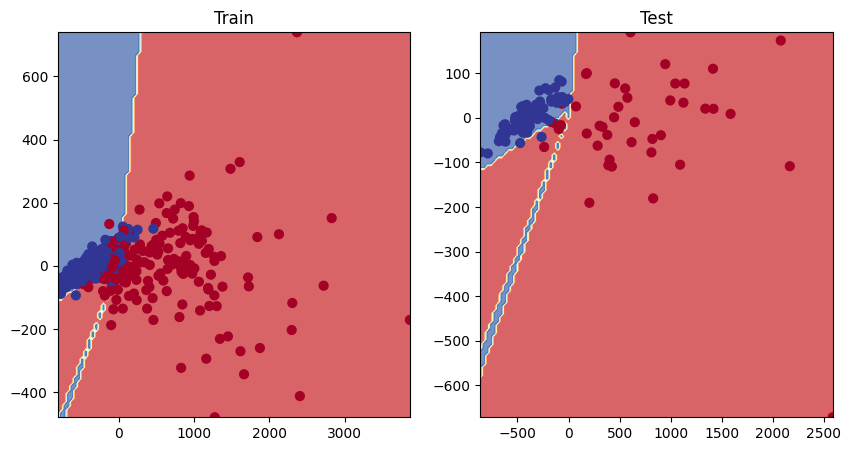

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test.cpu(), y_test.cpu())